In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Subset, random_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Normalisation standardisée sur [-1, 1]
transform_1d = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
transform_3d = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# ---------------------------------------------------------
# FASHION-MNIST (Exemple avec 30 000 images au lieu de 60 000)
# ---------------------------------------------------------
fmnist_full = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_1d)

# On sélectionne uniquement les 30 000 premiers indices
fmnist_subset = Subset(fmnist_full, range(30000))

# Séparation sur ce nouveau sous-ensemble (ex: 25k train, 5k validation)
fmnist_train, fmnist_val = random_split(fmnist_subset, [25000, 5000])

fmnist_trainloader = torch.utils.data.DataLoader(fmnist_train, batch_size=512, shuffle=True)
fmnist_valloader = torch.utils.data.DataLoader(fmnist_val, batch_size=512, shuffle=False)

# ---------------------------------------------------------
# CIFAR-10 (Limité à 30 000 images au lieu de 50 000)
# ---------------------------------------------------------
cifar_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_3d)

# On sélectionne uniquement les 30 000 premiers indices
cifar_subset = Subset(cifar_full, range(30000))

# Séparation sur ce nouveau sous-ensemble (ex: 25k train, 5k validation)
cifar_train, cifar_val = random_split(cifar_subset, [25000, 5000])

cifar_trainloader = torch.utils.data.DataLoader(cifar_train, batch_size=256, shuffle=True)
cifar_valloader = torch.utils.data.DataLoader(cifar_val, batch_size=256, shuffle=False)

# ---------------------------------------------------------
# DICTIONNAIRE DES DATASETS
# ---------------------------------------------------------
datasets = {
    "fMNIST": {"train": fmnist_trainloader, "val": fmnist_valloader, "input_dim": 784, "shape": (1, 28, 28)},
    "CIFAR10": {"train": cifar_trainloader, "val": cifar_valloader, "input_dim": 3072, "shape": (3, 32, 32)}
}

print("Datasets chargés et réduits avec succès !")
#print(f"Taille de l'entraînement CIFAR-10 : {len(cifar_train)} images")
#print(f"Taille de la validation CIFAR-10  : {len(cifar_val)} images")

Datasets chargés et réduits avec succès !


In [2]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, DataLoader

# LE DÉTAIL QUI SAUVE L'ARCHITECTURE : transforms.Pad(2)
transform_fmnist_padded = transforms.Compose([
    transforms.Pad(2), # Ajoute 2 pixels de bordure (28x28 -> 32x32)
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,))
])

print("Rechargement de Fashion-MNIST avec Padding (32x32)...")

# Application de la nouvelle transformation
fmnist_full_padded = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform_fmnist_padded)

# On refait la séparation Train/Val (ou Subset si tu avais limité à 30k)
fmnist_train, fmnist_val = random_split(fmnist_full_padded, [50000, 10000])

# Mise à jour stricte de ton dictionnaire de datasets
datasets["fMNIST"]["train"] = DataLoader(fmnist_train, batch_size=1024, shuffle=True)
datasets["fMNIST"]["val"] = DataLoader(fmnist_val, batch_size=1024, shuffle=False)

# Vérification
sample_images, _ = next(iter(datasets["fMNIST"]["train"]))
print(f"Nouvelle taille des images : {sample_images.shape} (Attendu: Batch x 1 x 32 x 32)")

Rechargement de Fashion-MNIST avec Padding (32x32)...
Nouvelle taille des images : torch.Size([1024, 1, 32, 32]) (Attendu: Batch x 1 x 32 x 32)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

class VGG5PredictiveCoding(nn.Module):
    def __init__(self, alpha_gen=1e-4, alpha_disc=1.0):
        super().__init__()
        self.L = 6 # 5 couches de transformation + 1 entrée = 6 niveaux d'états
        self.alpha_gen = alpha_gen
        self.alpha_disc = alpha_disc
        
        self.activation = nn.LeakyReLU()

        # ---------------------------------------------------------
        # VOIE ASCENDANTE (V) : Stride=2 remplace le MaxPool
        # ---------------------------------------------------------
        self.V = nn.ModuleList([
            nn.Conv2d(1, 128, kernel_size=3, stride=2, padding=1),       # 32x32 -> 16x16
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),     # 16x16 -> 8x8
            nn.Conv2d(256, 512, kernel_size=3, stride=2, padding=1),     # 8x8 -> 4x4
            nn.Conv2d(512, 512, kernel_size=3, stride=2, padding=0),     # 4x4 -> 1x1
            nn.Sequential(nn.Flatten(), nn.Linear(512, 10))              # 1x1 -> 10
        ])

        # ---------------------------------------------------------
        # VOIE DESCENDANTE (W) : ConvTranspose avec Stride=2
        # ---------------------------------------------------------
        self.W = nn.ModuleList([
            # L'output_padding permet de retrouver la dimension exacte lors du x2
            nn.ConvTranspose2d(128, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ConvTranspose2d(512, 256, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ConvTranspose2d(512, 512, kernel_size=3, stride=2, padding=0, output_padding=1),
            nn.Sequential(nn.Linear(10, 512), nn.Unflatten(1, (512, 1, 1)))
        ])

        # ---------------------------------------------------------
        # NORMALISATION : GroupNorm (Indépendant du batch !)
        # ---------------------------------------------------------
        # GroupNorm calcule les stats par image. Fini l'entremêlement toxique.
        self.norms_disc = nn.ModuleList([
            nn.GroupNorm(32, 128),
            nn.GroupNorm(32, 256),
            nn.GroupNorm(32, 512),
            nn.GroupNorm(32, 512),
            nn.LayerNorm(10) # Équivalent 1D pour la dernière couche
        ])

        self.norms_gen = nn.ModuleList([
            nn.Identity(), # Pas de normalisation sur l'image brute reconstruite
            nn.GroupNorm(32, 128),
            nn.GroupNorm(32, 256),
            nn.GroupNorm(32, 512),
            nn.GroupNorm(32, 512)
        ])

    def compute_energy(self, x, t=None, lr_x=0.01):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            sigma = 1.0
            if t is not None and (i + 1) == (self.L - 1) - t:
                sigma = lr_x  # Spiking Precision
            
            pred_gen = self.norms_gen[i](self.W[i](self.activation(x[i+1])))
            # UTILISATION DE torch.mean() AU LIEU DE torch.sum()
            energy_gen += torch.mean((x[i] - pred_gen) ** 2) * (self.alpha_gen / (2 * sigma))
            
            pred_disc = self.norms_disc[i](self.V[i](self.activation(x[i])))
            energy_disc += torch.mean((x[i+1] - pred_disc) ** 2) * (self.alpha_disc / (2 * sigma))
            
        return energy_gen + energy_disc

    def compute_forward_update_energy(self, x_T, x_init):
        energy_gen = 0.0
        energy_disc = 0.0
        for i in range(self.L - 1):
            pred_gen_0 = self.norms_gen[i](self.W[i](self.activation(x_init[i+1].detach())))
            energy_gen += torch.mean((x_T[i].detach() - pred_gen_0) ** 2) * (self.alpha_gen / 2)
            
            pred_disc_0 = self.norms_disc[i](self.V[i](self.activation(x_init[i].detach())))
            energy_disc += torch.mean((x_T[i+1].detach() - pred_disc_0) ** 2) * (self.alpha_disc / 2)
        return energy_gen + energy_disc

    def bottom_up_sweep(self, x1):
        x = [x1.clone()]
        with torch.no_grad():
            for i in range(self.L - 1):
                x.append(self.norms_disc[i](self.V[i](self.activation(x[-1]))))
        return x

    def infer(self, x_init, clamped_indices, steps=8, lr_x=0.01):
        x = [tensor.clone() for tensor in x_init]
        free_params = []
        for i in range(self.L):
            if i not in clamped_indices:
                x[i].requires_grad = True
                free_params.append(x[i])
                
        if len(free_params) > 0:
            optimizer_x = optim.SGD(free_params, lr=lr_x, momentum=0.0)
            # Plus besoin d'activer/désactiver le BN Freezing ici
            for step in range(1, steps + 1):
                optimizer_x.zero_grad()
                energy = self.compute_energy(x, t=step, lr_x=lr_x)
                energy.backward()
                optimizer_x.step()
        return [tensor.detach() for tensor in x]

In [4]:
import torch
import torch.optim as optim

# ASSURE-TOI d'avoir bien tes images padées en 32x32 avec transforms.Pad(2) !

# 1. Instanciation du modèle VGG5 propre
vgg5_fmnist = VGG5PredictiveCoding(alpha_gen=1e-4, alpha_disc=1.0).to(device)

# 2. Optimiseur (Taux d'apprentissage potentiellement plus élevé grâce à la stabilité de mean)
optimizer_weights = optim.AdamW(vgg5_fmnist.parameters(), lr=1e-3, weight_decay=1e-4)

epochs = 15
print("Début de l'entraînement VGG5 sur Fashion-MNIST...")

for epoch in range(epochs):
    vgg5_fmnist.train()
    total_loss = 0.0
    
    for images, labels in datasets["fMNIST"]["train"]:
        # Images conservées en 2D (B, C, H, W)
        x1_input = images.to(device)
        
        # Initialisation hiérarchique
        x_init = vgg5_fmnist.bottom_up_sweep(x1_input)
        
        # Fixation du label one-hot
        xL_label = torch.nn.functional.one_hot(labels, num_classes=10).float().to(device)
        x_init[-1] = xL_label
        
        # Inférence courte (T=8 suffisent avec la Spiking Precision)
        x_inferred = vgg5_fmnist.infer(x_init, clamped_indices=[0, 5], steps=8, lr_x=0.01)
        
        # Mise à jour des poids
        optimizer_weights.zero_grad()
        loss = vgg5_fmnist.compute_forward_update_energy(x_T=x_inferred, x_init=x_init)
        loss.backward()
        optimizer_weights.step()
        
        total_loss += loss.item()
        
    print(f"Epoch {epoch+1}/{epochs} | Perte (Forward Update Energy) : {total_loss/len(datasets['fMNIST']['train']):.4f}")

Début de l'entraînement VGG5 sur Fashion-MNIST...
Epoch 1/15 | Perte (Forward Update Energy) : 0.3785
Epoch 2/15 | Perte (Forward Update Energy) : 0.2974
Epoch 3/15 | Perte (Forward Update Energy) : 0.2512
Epoch 4/15 | Perte (Forward Update Energy) : 0.2085
Epoch 5/15 | Perte (Forward Update Energy) : 0.1676
Epoch 6/15 | Perte (Forward Update Energy) : 0.1303
Epoch 7/15 | Perte (Forward Update Energy) : 0.0985
Epoch 8/15 | Perte (Forward Update Energy) : 0.0734
Epoch 9/15 | Perte (Forward Update Energy) : 0.0549
Epoch 10/15 | Perte (Forward Update Energy) : 0.0420
Epoch 11/15 | Perte (Forward Update Energy) : 0.0335
Epoch 12/15 | Perte (Forward Update Energy) : 0.0280
Epoch 13/15 | Perte (Forward Update Energy) : 0.0247
Epoch 14/15 | Perte (Forward Update Energy) : 0.0228
Epoch 15/15 | Perte (Forward Update Energy) : 0.0216


In [ ]:
import torch

print("\n--- ÉVALUATION fMNIST (MODÈLE VGG5 SUPERVISÉ) ---")

# On passe le bon modèle en mode évaluation
vgg5_fmnist.eval()

total_correct_sup = 0
total_samples_sup = 0

for images, labels in datasets["fMNIST"]["val"]:
    # 1. SUPPRESSION DU .view() : On garde le format (Batch, 1, 32, 32)
    x1_input = images.to(device)
    labels = labels.to(device)
    batch_size = x1_input.size(0)
    
    # ---------------------------------------------------------
    # CLASSIFICATION NATIVE
    # ---------------------------------------------------------
    # Initialisation de la hiérarchie convolutive
    x_init_class = vgg5_fmnist.bottom_up_sweep(x1_input)
    
    # On fige l'entrée (indice 0) et on laisse les couches 1 à 5 converger
    x_res_class = vgg5_fmnist.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # La dernière couche (indice -1 ou 5) contient les logits de classification (Batch, 10)
    preds = torch.argmax(x_res_class[-1], dim=1)
    total_correct_sup += (preds == labels).sum().item()
    
    total_samples_sup += batch_size

acc_sup = 100 * total_correct_sup / total_samples_sup

print(f"-> Précision de classification (VGG5) : {acc_sup:.2f}%")


--- ÉVALUATION fMNIST (MODÈLE VGG5 SUPERVISÉ) ---


Extraction des 6 couches du modèle VGG5...
Calcul t-SNE pour la couche 0...
Calcul t-SNE pour la couche 1...
Calcul t-SNE pour la couche 2...
Calcul t-SNE pour la couche 3...
Calcul t-SNE pour la couche 4...
Calcul t-SNE pour la couche 5...


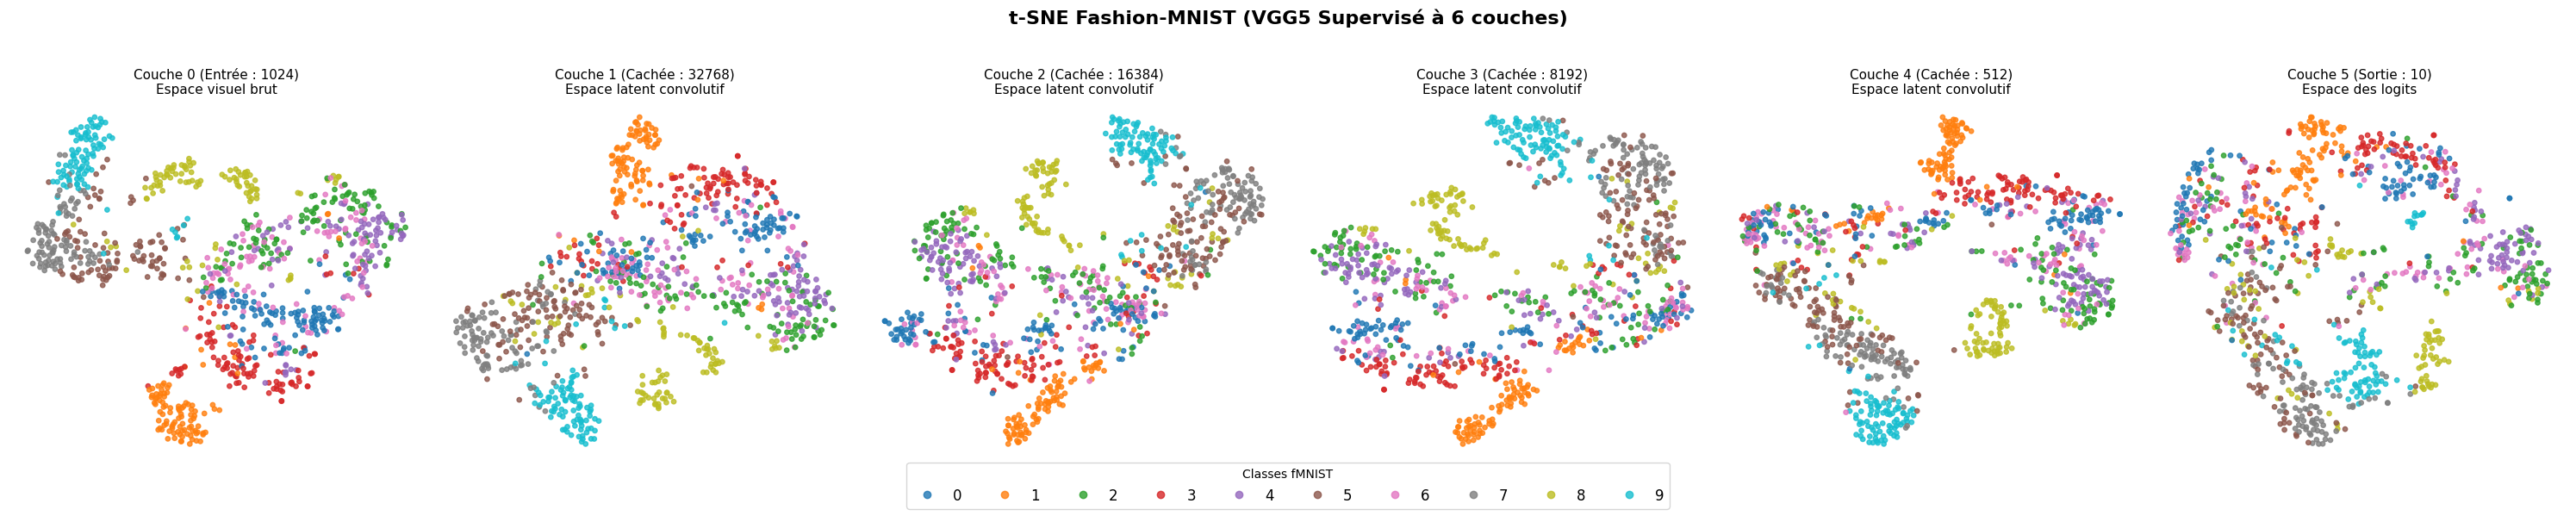

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# VISUALISATION t-SNE POUR VGG5
# ---------------------------------------------------------
vgg5_fmnist=vgg5_fmnist
vgg5_fmnist.eval()
num_samples = 1000

# Le VGG5 a 6 niveaux d'états (L=6)
num_layers = vgg5_fmnist.L
latents_per_layer = [[] for _ in range(num_layers)]
targets_tsne = []

print(f"Extraction des {num_layers} couches du modèle VGG5...")

for images, labels in datasets["fMNIST"]["val"]:
    # L'image reste au format (B, C, H, W) pour entrer dans la convolution
    x_in = images.to(device)
    batch_size = x_in.size(0)
    
    # Inférence
    x_init = vgg5_fmnist.bottom_up_sweep(x_in)
    x_infer = vgg5_fmnist.infer(x_init, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # Extraction dynamique avec aplatissement pour t-SNE
    for i in range(num_layers):
        # On aplatit chaque état latent : (B, C, H, W) -> (B, C*H*W)
        flat_tensor = x_infer[i].view(batch_size, -1).detach().cpu().numpy()
        latents_per_layer[i].append(flat_tensor)
        
    targets_tsne.append(labels.numpy())
    
    if sum(len(t) for t in targets_tsne) >= num_samples: 
        break

# Concaténation dynamique
Z_layers = [np.concatenate(latents)[:num_samples] for latents in latents_per_layer]
Y_tsne = np.concatenate(targets_tsne)[:num_samples]

# ---------------------------------------------------------
# AFFICHAGE
# ---------------------------------------------------------
fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 6))

if num_layers == 1: axes = [axes]

fig.suptitle(f"t-SNE Fashion-MNIST (VGG5 Supervisé à {num_layers} couches)", fontsize=16, fontweight='bold')
tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')

for i in range(num_layers):
    ax = axes[i]
    print(f"Calcul t-SNE pour la couche {i}...")
    
    z_tsne = tsne.fit_transform(Z_layers[i])
    sc = ax.scatter(z_tsne[:, 0], z_tsne[:, 1], c=Y_tsne, cmap='tab10', s=15, alpha=0.8)
    
    # Calcul du nombre total de caractéristiques (Features) pour le titre
    layer_features = Z_layers[i].shape[1]
    
    if i == 0:
        title = f"Couche 0 (Entrée : {layer_features})\nEspace visuel brut"
    elif i == num_layers - 1:
        title = f"Couche {i} (Sortie : {layer_features})\nEspace des logits"
    else:
        title = f"Couche {i} (Cachée : {layer_features})\nEspace latent convolutif"
        
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, labels_plot = sc.legend_elements()
fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes fMNIST", fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

In [1]:
print("\n--- ÉVALUATION CIFAR-10 (MODÈLE SUPERVISÉ) ---")
vgg5_fmnist.eval()

total_correct_sup = 0
total_comp_mse_sup = 0
total_samples_sup = 0
epsilon_sup = 1e-5

# Masque pour la complétion (moitié haute conservée)
channels, h, w = datasets["fMNIST"]["shape"]
mask_2d_sup = torch.zeros((channels, h, w), device=device)
mask_2d_sup[:, :h//2, :] = 1.0  
missing_ratio_sup = 0.50

for images, labels in datasets["fMNIST"]["val"]:
    x1_input = images.view(images.size(0), -1).to(device)
    labels = labels.to(device)
    batch_size = x1_input.size(0)
    
    # ---------------------------------------------------------
    # 1. CLASSIFICATION NATIVE
    # ---------------------------------------------------------
    x_init_class = vgg5_fmnist.bottom_up_sweep(x1_input)
    # On fige l'entrée, on laisse la couche 2 converger vers la prédiction
    x_res_class = vgg5_fmnist.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
    preds = torch.argmax(x_res_class[-1], dim=1)
    total_correct_sup += (preds == labels).sum().item()
    
    # ---------------------------------------------------------
    # 2. COMPLÉTION (Moitié Basse)
    # ---------------------------------------------------------
    known_mask = mask_2d_sup.view(-1).unsqueeze(0).expand_as(x1_input)
    missing_mask = 1.0 - known_mask
    occluded_images = x1_input * known_mask
    
    x_init_comp = vgg5_fmnist.bottom_up_sweep(occluded_images)
    x_comp = [t.clone().detach() for t in x_init_comp]
    for i in range(vgg5_fmnist.L): x_comp[i].requires_grad = True
    opt_comp = optim.SGD(x_comp, lr=0.01)
    
    # Phase 1: Warm-up
    orig_alpha_disc = vgg5_fmnist.alpha_disc
    vgg5_fmnist.alpha_disc = 0.0
    prev_en = float('inf')
    for _ in range(500):
        opt_comp.zero_grad()
        en = vgg5_fmnist.compute_energy(x_comp)
        en.backward()
        x_comp[0].grad.data *= missing_mask
        opt_comp.step()
        if abs(prev_en - en.item()) < epsilon_sup: break
        prev_en = en.item()
        
    # Phase 2: Bidirectionnel
    vgg5_fmnist.alpha_disc = orig_alpha_disc
    prev_en = float('inf')
    for _ in range(500):
        opt_comp.zero_grad()
        en = vgg5_fmnist.compute_energy(x_comp)
        en.backward()
        x_comp[0].grad.data *= missing_mask
        opt_comp.step()
        if abs(prev_en - en.item()) < epsilon_sup: break
        prev_en = en.item()
        
    diff_comp = (x_comp[0].detach() - x1_input) * missing_mask
    total_comp_mse_sup += torch.sum(diff_comp ** 2).item()
    
    total_samples_sup += batch_size

acc_sup = 100 * total_correct_sup / total_samples_sup
rmse_comp_sup = math.sqrt(total_comp_mse_sup / (total_samples_sup * 3072 * missing_ratio_sup))

print(f"-> Précision de classification : {acc_sup:.2f}%")
print(f"-> RMSE Complétion (moitié basse) : {rmse_comp_sup:.4f}")


--- ÉVALUATION CIFAR-10 (MODÈLE SUPERVISÉ) ---


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [256, 1024]

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ---------------------------------------------------------
# DÉFINITION DU MODÈLE À TESTER
# (Assure-toi que ce modèle a été entraîné sur fMNIST au préalable)
# ---------------------------------------------------------
current_model = vgg5_fmnist 
current_model.eval()

num_samples = 1000

# Création d'une liste de listes vide pour chaque couche du modèle
latents_per_layer = [[] for _ in range(current_model.L)]
targets_tsne = []

print(f"Extraction des {current_model.L} couches du modèle...")

for images, labels in datasets["fMNIST"]["val"]:
    x_in = images.view(images.size(0), -1).to(device)
    
    # Inférence
    x_init = current_model.bottom_up_sweep(x_in)
    x_infer = current_model.infer(x_init, clamped_indices=[0], steps=100, lr_x=0.01)
    
    # Extraction dynamique pour chaque couche
    for i in range(current_model.L):
        latents_per_layer[i].append(x_infer[i].detach().cpu().numpy())
        
    targets_tsne.append(labels.numpy())
    
    if sum(len(t) for t in targets_tsne) >= num_samples: 
        break

# Concaténation dynamique
Z_layers = [np.concatenate(latents)[:num_samples] for latents in latents_per_layer]
Y_tsne = np.concatenate(targets_tsne)[:num_samples]

# ---------------------------------------------------------
# AFFICHAGE DYNAMIQUE
# ---------------------------------------------------------
num_layers = current_model.L
# La largeur de la figure s'adapte au nombre de couches (5 pouces par couche)
fig, axes = plt.subplots(1, num_layers, figsize=(5 * num_layers, 6))

# Si le modèle n'avait que 1 couche (peu probable, mais sécurisé), axes n'est pas une liste
if num_layers == 1:
    axes = [axes]

fig.suptitle(f"t-SNE Fashion-MNIST (Modèle Dynamique à {num_layers} couches)", fontsize=16, fontweight='bold')

tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')

for i in range(num_layers):
    ax = axes[i]
    print(f"Calcul t-SNE pour la couche {i}...")
    
    z_tsne = tsne.fit_transform(Z_layers[i])
    sc = ax.scatter(z_tsne[:, 0], z_tsne[:, 1], c=Y_tsne, cmap='tab10', s=15, alpha=0.8)
    
    layer_size = Z_layers[i].shape[1]
    
    # Titres dynamiques selon la position de la couche
    if i == 0:
        title = f"Couche 0 (Entrée : {layer_size})\nEspace visuel brut"
    elif i == num_layers - 1:
        title = f"Couche {i} (Sortie : {layer_size})\nEspace des prédictions"
    else:
        title = f"Couche {i} (Cachée : {layer_size})\nEspace latent intermédiaire"
        
    ax.set_title(title, fontsize=11)
    ax.axis('off')

# Légende globale
handles, labels_plot = sc.legend_elements()
fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes fMNIST", fontsize=12)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

Extraction des 6 couches du modèle...


RuntimeError: Expected 3D (unbatched) or 4D (batched) input to conv2d, but got input of size: [256, 1024]

In [ ]:
import torch.optim as optim

def train_bpc_model(model, dataloader, epochs=25, is_mixed=False):
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=5e-3)
    latent_mask = torch.zeros(30, device=device)
    if is_mixed:
        latent_mask[:10] = 1.0
        
    for epoch in range(epochs):
        model.train()
        total_energy = 0
        for images, labels in dataloader:
            x1_input = images.view(images.size(0), -1).to(device)
            x_init = model.bottom_up_sweep(x1_input)
            x_init[0] = x1_input
            
            if is_mixed:
                xL_label = torch.zeros((x1_input.size(0), 30), device=device)
                xL_label[:, :10] = torch.nn.functional.one_hot(labels, num_classes=10).float()
                x_init[-1][:, :10] = xL_label[:, :10]
                x_inferred = model.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, partial_clamp=(2, latent_mask.unsqueeze(0)))
            else:
                x_inferred = model.infer(x_init, clamped_indices=[0], steps=8, lr_x=0.01, activity_decay=1e-4)
                
            optimizer.zero_grad()
            loss = model.compute_energy(x_inferred)
            loss.backward()
            optimizer.step()
            total_energy += loss.item()
            
        print(f"Epoch {epoch+1}/{epochs} | Énergie : {total_energy/len(dataloader):.4f}")
    return model

# ---------------------------------------------------------
# INSTANCIATION ET ENTRAÎNEMENT POUR FASHION-MNIST
# ---------------------------------------------------------
print("--- ENTRAÎNEMENT FASHION-MNIST ---")
fmnist_unsup = BidirectionalPC(layer_sizes=[784, 450, 30], alpha_gen=1.0, alpha_disc=1.0).to(device)
fmnist_mixed = MixedBidirectionalPC(layer_sizes=[784, 450, 30], alpha_gen=1e-4, alpha_disc=1.0).to(device)

print("Entraînement fMNIST Non-Supervisé :")
fmnist_unsup = train_bpc_model(fmnist_unsup, datasets["fMNIST"]["train"], epochs=25, is_mixed=False)
print("Entraînement fMNIST Mixte :")
fmnist_mixed = train_bpc_model(fmnist_mixed, datasets["fMNIST"]["train"], epochs=25, is_mixed=True)

# ---------------------------------------------------------
# INSTANCIATION ET ENTRAÎNEMENT POUR CIFAR-10
# ---------------------------------------------------------
print("\n--- ENTRAÎNEMENT CIFAR-10 ---")
cifar_unsup = BidirectionalPC(layer_sizes=[3072, 450, 30], alpha_gen=1.0, alpha_disc=1.0).to(device)
cifar_mixed = MixedBidirectionalPC(layer_sizes=[3072, 450, 30], alpha_gen=1e-4, alpha_disc=1.0).to(device)

print("Entraînement CIFAR-10 Non-Supervisé :")
cifar_unsup = train_bpc_model(cifar_unsup, datasets["CIFAR10"]["train"], epochs=25, is_mixed=False)
print("Entraînement CIFAR-10 Mixte :")
cifar_mixed = train_bpc_model(cifar_mixed, datasets["CIFAR10"]["train"], epochs=25, is_mixed=True)

In [ ]:
import math
import torch.nn as nn

def evaluate_model(model, dataloader, ds_info, is_mixed=False):
    model.eval()
    input_dim = ds_info["input_dim"]
    channels, h, w = ds_info["shape"]
    
    # Masque Géométrique adapté à l'image
    mask_2d = torch.zeros((channels, h, w), device=device)
    mask_2d[:, :h//2, :] = 1.0  # Conserve la moitié haute
    
    total_recon_mse, total_comp_mse = 0, 0
    total_correct_native = 0
    total_samples = 0
    epsilon = 1e-5
    
    for images, labels in dataloader:
        x1_input = images.view(images.size(0), -1).to(device)
        labels = labels.to(device)
        batch_size = x1_input.size(0)
        
        # 1. RECONSTRUCTION
        x_init_enc = model.bottom_up_sweep(x1_input)
        x_enc = [t.clone().detach() for t in x_init_enc]
        for i in range(1, model.L): x_enc[i].requires_grad = True
        opt_enc = optim.SGD([x_enc[i] for i in range(1, model.L)], lr=0.01)
        prev_en = float('inf')
        for _ in range(500):
            opt_enc.zero_grad()
            en = model.compute_energy(x_enc)
            en.backward()
            opt_enc.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        x_init_dec = model.top_down_sweep(x_enc[-1].detach())
        x_dec = [t.clone().detach() for t in x_init_dec]
        for i in range(model.L - 1): x_dec[i].requires_grad = True
        opt_dec = optim.SGD([x_dec[i] for i in range(model.L - 1)], lr=0.01)
        prev_en = float('inf')
        for _ in range(500):
            opt_dec.zero_grad()
            en = model.compute_energy(x_dec)
            en.backward()
            opt_dec.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        total_recon_mse += torch.sum((x_dec[0].detach() - x1_input) ** 2).item()
        
        # 2. COMPLÉTION
        known_mask = mask_2d.view(-1).unsqueeze(0).expand_as(x1_input)
        missing_mask = 1.0 - known_mask
        
        x_init_comp = model.bottom_up_sweep(x1_input * known_mask)
        x_comp = [t.clone().detach() for t in x_init_comp]
        for i in range(model.L): x_comp[i].requires_grad = True
        opt_comp = optim.SGD(x_comp, lr=0.01)
        
        # Phase 1: Warm-up
        orig_alpha_disc = model.alpha_disc
        model.alpha_disc = 0.0
        prev_en = float('inf')
        for _ in range(500):
            opt_comp.zero_grad()
            en = model.compute_energy(x_comp)
            en.backward()
            x_comp[0].grad.data *= missing_mask
            opt_comp.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        # Phase 2: Bidirectionnel
        model.alpha_disc = orig_alpha_disc
        prev_en = float('inf')
        for _ in range(500):
            opt_comp.zero_grad()
            en = model.compute_energy(x_comp)
            en.backward()
            x_comp[0].grad.data *= missing_mask
            opt_comp.step()
            if abs(prev_en - en.item()) < epsilon: break
            prev_en = en.item()
            
        diff_comp = (x_comp[0].detach() - x1_input) * missing_mask
        total_comp_mse += torch.sum(diff_comp ** 2).item()
        
        # 3. CLASSIFICATION NATIVE (Si Mixte)
        if is_mixed:
            x_init_class = model.bottom_up_sweep(x1_input)
            x_res_class = model.infer(x_init_class, clamped_indices=[0], steps=100, lr_x=0.01)
            preds = torch.argmax(x_res_class[-1][:, :10], dim=1)
            total_correct_native += (preds == labels).sum().item()
            
        total_samples += batch_size

    rmse_recon = math.sqrt(total_recon_mse / (total_samples * input_dim))
    rmse_comp = math.sqrt(total_comp_mse / (total_samples * input_dim * 0.5))
    
    print(f"  -> RMSE Reconstruction: {rmse_recon:.4f}")
    print(f"  -> RMSE Complétion (bas): {rmse_comp:.4f}")
    if is_mixed:
        print(f"  -> Précision Native: {100 * total_correct_native / total_samples:.2f}%")

print("\n--- ÉVALUATION FASHION-MNIST ---")
print("[Non-Supervisé]")
evaluate_model(fmnist_unsup, datasets["fMNIST"]["val"], datasets["fMNIST"], is_mixed=False)
print("[Mixte]")
evaluate_model(fmnist_mixed, datasets["fMNIST"]["val"], datasets["fMNIST"], is_mixed=True)

print("\n--- ÉVALUATION CIFAR-10 ---")
print("[Non-Supervisé]")
evaluate_model(cifar_unsup, datasets["CIFAR10"]["val"], datasets["CIFAR10"], is_mixed=False)
print("[Mixte]")
evaluate_model(cifar_mixed, datasets["CIFAR10"]["val"], datasets["CIFAR10"], is_mixed=True)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_comparison(model_unsup, model_mixed, dataloader, title_prefix):
    model_unsup.eval()
    model_mixed.eval()
    
    latents_u, latents_m, targets = [], [], []
    num_samples = 1000
    
    for images, labels in dataloader:
        x_in = images.view(images.size(0), -1).to(device)
        
        # Extraction Unsup
        xu_init = model_unsup.bottom_up_sweep(x_in)
        xu = [t.clone().detach() for t in xu_init]
        for i in range(1, model_unsup.L): xu[i].requires_grad = True
        op_u = optim.SGD([xu[i] for i in range(1, model_unsup.L)], lr=0.01)
        for _ in range(100):
            op_u.zero_grad()
            model_unsup.compute_energy(xu).backward()
            op_u.step()
            
        # Extraction Mixte
        xm_init = model_mixed.bottom_up_sweep(x_in)
        xm = [t.clone().detach() for t in xm_init]
        for i in range(1, model_mixed.L): xm[i].requires_grad = True
        op_m = optim.SGD([xm[i] for i in range(1, model_mixed.L)], lr=0.01)
        for _ in range(100):
            op_m.zero_grad()
            model_mixed.compute_energy(xm).backward()
            op_m.step()
            
        latents_u.append(xu[-1].detach().cpu().numpy())
        latents_m.append(xm[-1].detach().cpu().numpy())
        targets.append(labels.numpy())
        
        if sum(len(t) for t in targets) >= num_samples: break
            
    Z_u = np.concatenate(latents_u)[:num_samples]
    Z_m = np.concatenate(latents_m)[:num_samples]
    Y = np.concatenate(targets)[:num_samples]
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"t-SNE Espace Latent (Couche Supérieure) - {title_prefix}", fontsize=14, fontweight='bold')
    
    tsne = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto')
    
    ax1 = axes[0]
    z_u_tsne = tsne.fit_transform(Z_u)
    sc1 = ax1.scatter(z_u_tsne[:, 0], z_u_tsne[:, 1], c=Y, cmap='tab10', s=15, alpha=0.8)
    ax1.set_title("Modèle Non-Supervisé")
    ax1.axis('off')
    
    ax2 = axes[1]
    z_m_tsne = tsne.fit_transform(Z_m)
    ax2.scatter(z_m_tsne[:, 0], z_m_tsne[:, 1], c=Y, cmap='tab10', s=15, alpha=0.8)
    ax2.set_title("Modèle Mixte")
    ax2.axis('off')
    
    handles, labels_plot = sc1.legend_elements()
    fig.legend(handles, [str(i) for i in range(10)], loc='lower center', ncol=10, title="Classes")
    plt.tight_layout(rect=[0, 0.08, 1, 0.95])
    plt.show()

# Affichage pour fMNIST
plot_tsne_comparison(fmnist_unsup, fmnist_mixed, datasets["fMNIST"]["val"], "Fashion-MNIST")

# Affichage pour CIFAR-10
plot_tsne_comparison(cifar_unsup, cifar_mixed, datasets["CIFAR10"]["val"], "CIFAR-10")